# Month label edge cases

Tests month label alignment when the data starts part-way through January.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from seasonal_spirals.spiral import SeasonalSpiral

In [2]:
def make_data(start, end, seed=42):
    """Synthetic daily data with a strong February spike (Six Nations-ish)."""
    dates = pd.date_range(start, end, freq='D')
    rng = np.random.default_rng(seed)
    values = rng.integers(200, 800, size=len(dates)).astype(float)
    # Spike every February
    for dt, v in zip(dates, values):
        if dt.month == 2:
            values[dates.get_loc(dt)] = rng.integers(5000, 50000)
    return pd.Series(values, index=dates, name='synthetic')

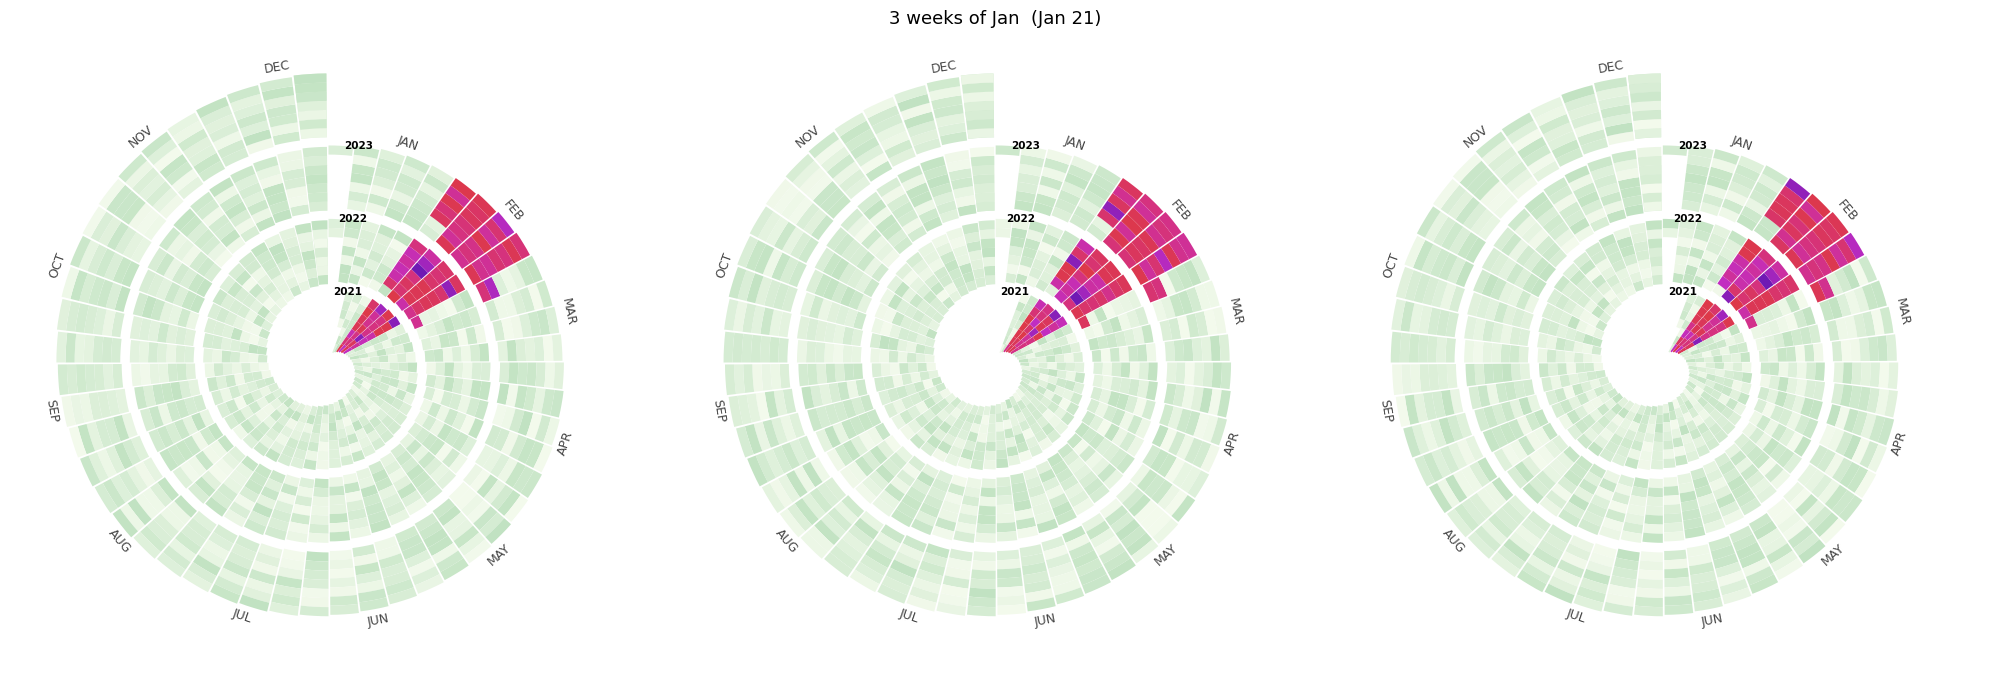

In [3]:
cases = {
    '2 weeks of Jan  (Jan 14)': make_data('2021-01-14', '2023-12-31'),
    '2.5 weeks of Jan (Jan 18)': make_data('2021-01-18', '2023-12-31'),
    '3 weeks of Jan  (Jan 21)': make_data('2021-01-21', '2023-12-31'),
}

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (label, data) in zip(axes, cases.items()):
    SeasonalSpiral(data, title=label, max_years=3).plot(ax=ax)

fig.tight_layout()
plt.show()